LEO to GEO Chemical-Thruster Transfer - Basilisk Implementation
Initial altitude:             622.0 km
Target altitude:              35622.0 km
Initial circular speed:       7.546049 km/s
Target circular speed:        3.080662 km/s
Chemical thrust:              500.0 N
Specific impulse:             320.0 s
Initial mass:                 300.0 kg
Hohmann burn 1 Δv:            2334.048 m/s
Hohmann burn 2 Δv:            1433.979 m/s
Ideal total Δv:               3768.027 m/s

PHASE 1 - PERIGEE BURN TO ENTER HOHMANN TRANSFER
Burn 1 duration:              989.0 s
Burn 1 estimated delivered Δv:2336.946 m/s
Burn 1 propellant used:       157.578 kg
Post-burn eccentricity:       0.693165
Post-burn estimated apogee:   33184.35 km altitude

PHASE 2 - COAST TO APOGEE
Time to apogee:               5.085 hr
Apogee altitude reached:      33184.35 km
Eccentricity at apogee:       0.693165

PHASE 3 - APOGEE CIRCULARIZATION BURN
Burn 2 duration:              329.0 s
Burn 2 estimated delivered Δv:1439.254

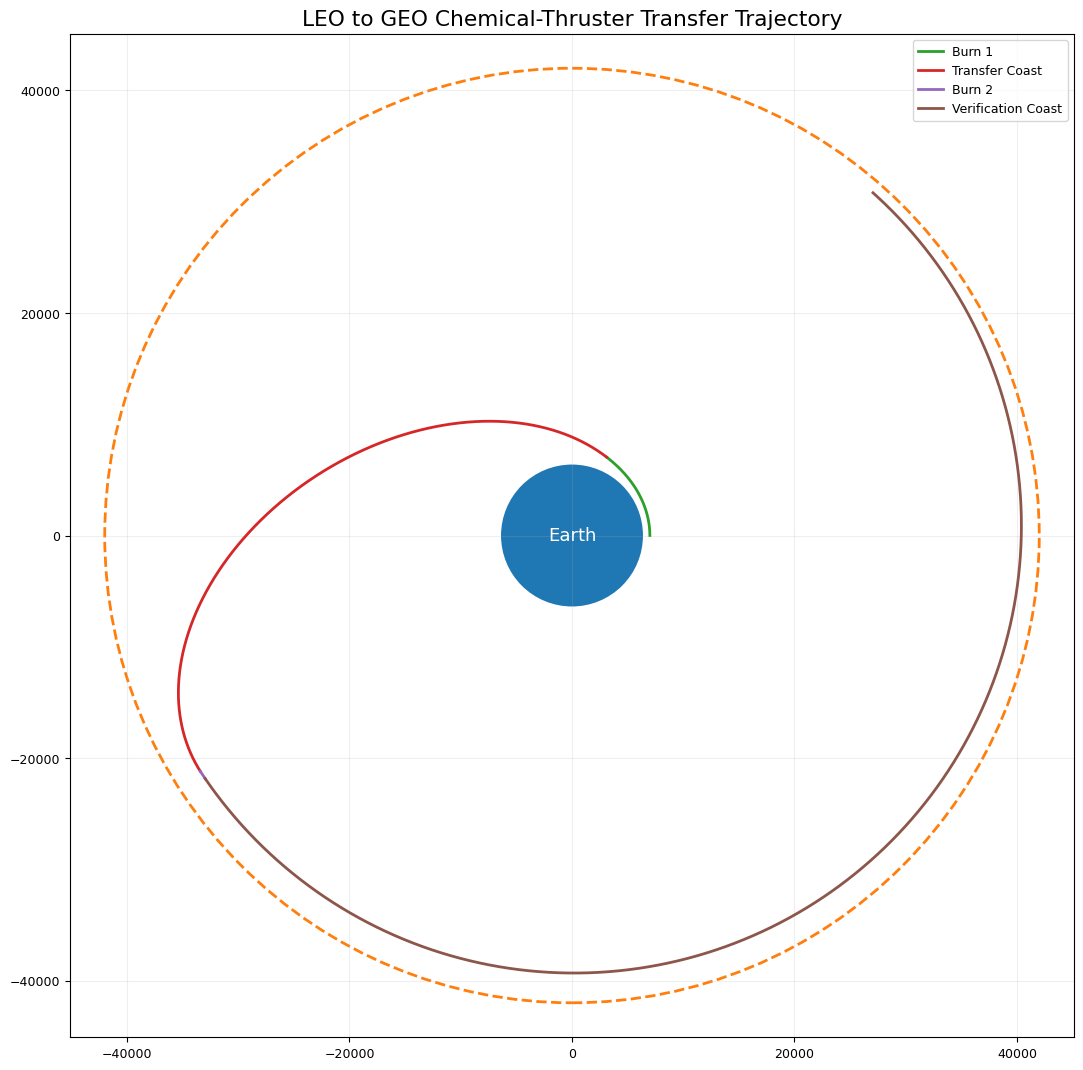

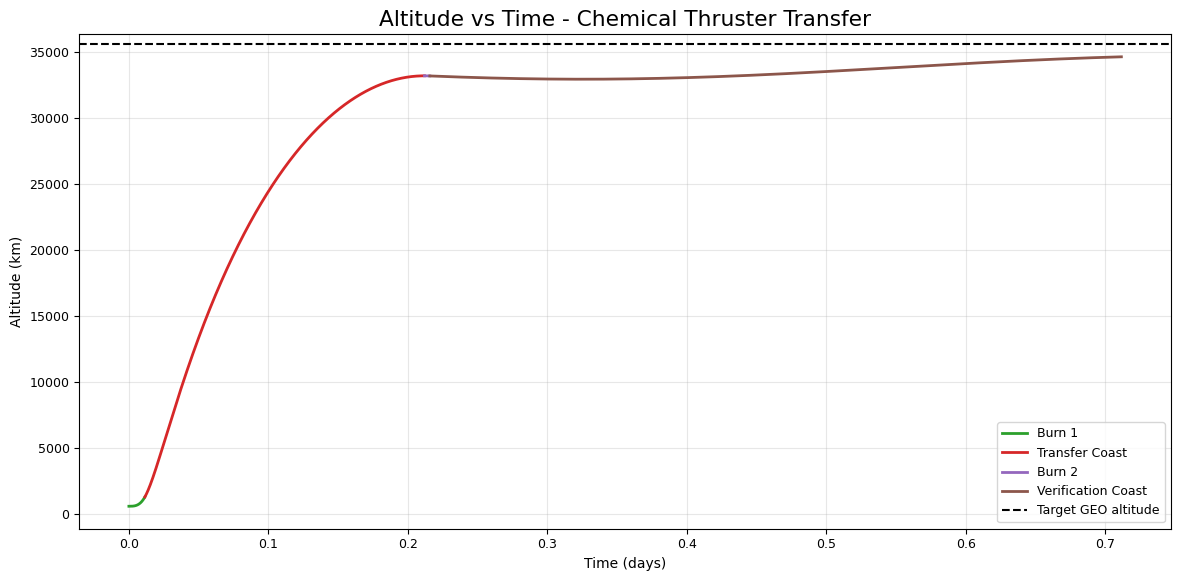

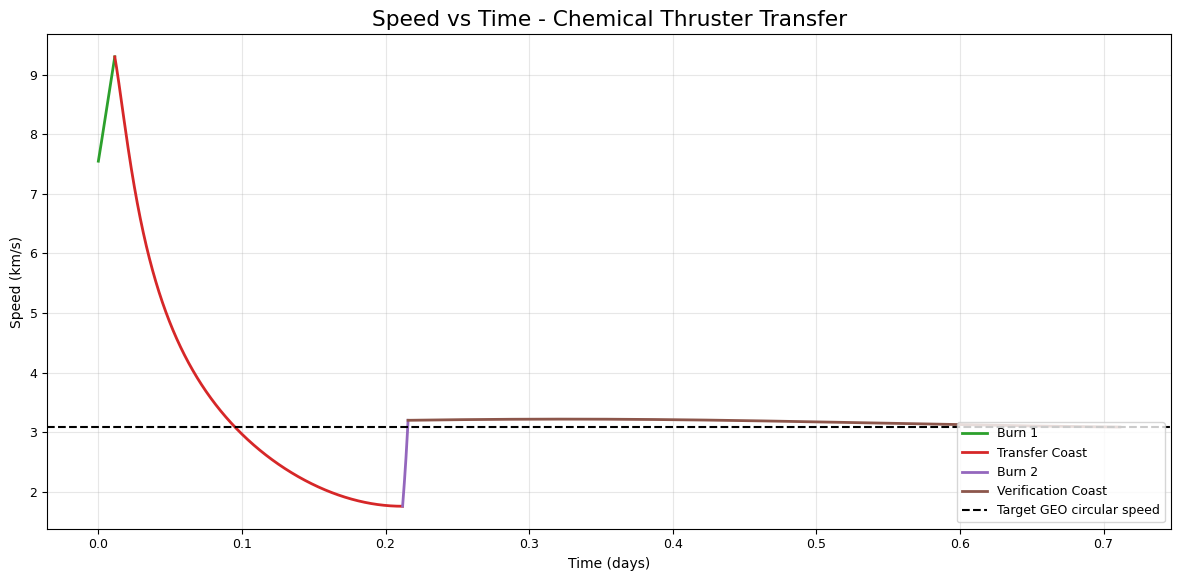

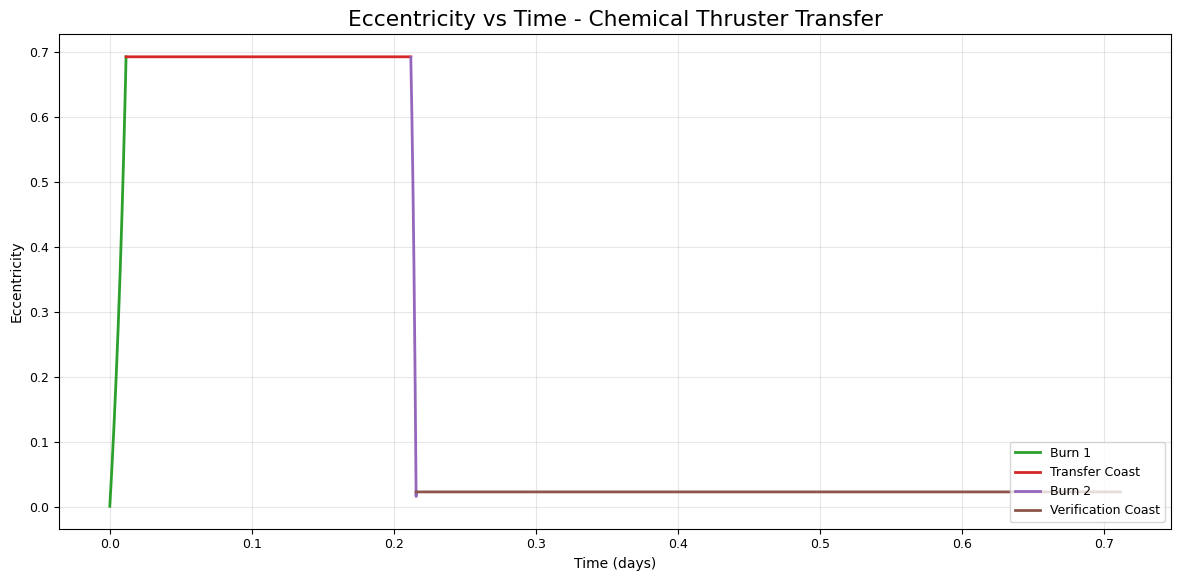

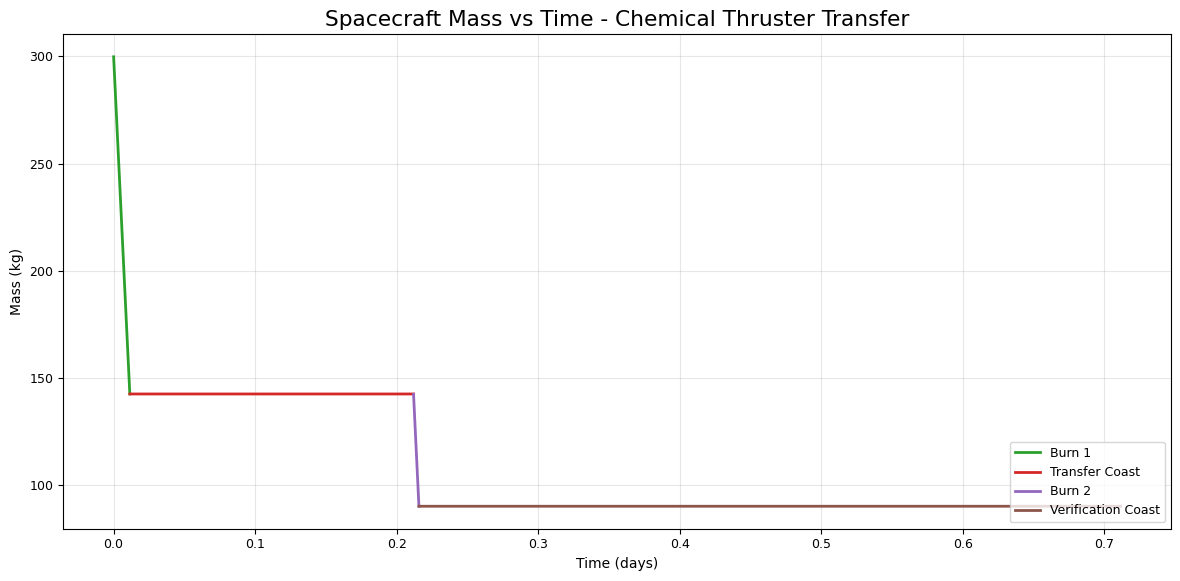

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

from Basilisk import __path__
from Basilisk.simulation import spacecraft
from Basilisk.simulation import extForceTorque
from Basilisk.simulation import simpleNav
from Basilisk.utilities import SimulationBaseClass
from Basilisk.utilities import macros
from Basilisk.utilities import unitTestSupport
from Basilisk.utilities import simIncludeGravBody

bskPath = __path__[0]


def orbital_elements_from_state(r_vec_km, v_vec_km_s, mu):
    r_mag = np.linalg.norm(r_vec_km)
    v_mag = np.linalg.norm(v_vec_km_s)
    h_vec = np.cross(r_vec_km, v_vec_km_s)
    h_mag = np.linalg.norm(h_vec)
    e_vec = np.cross(v_vec_km_s, h_vec) / mu - r_vec_km / r_mag
    e_mag = np.linalg.norm(e_vec)
    energy = 0.5 * v_mag**2 - mu / r_mag
    if abs(energy) > 1e-14:
        a = -mu / (2.0 * energy)
    else:
        a = np.inf
    rp = a * (1.0 - e_mag) if np.isfinite(a) else np.nan
    ra = a * (1.0 + e_mag) if np.isfinite(a) else np.nan
    return {
        "r_mag": r_mag,
        "v_mag": v_mag,
        "h_mag": h_mag,
        "e_vec": e_vec,
        "e_mag": e_mag,
        "energy": energy,
        "a": a,
        "rp": rp,
        "ra": ra,
    }


# --- NEW / CHANGED (CHEMICAL THRUSTER VERSION) ---
def run(show_plots=True):
    """
    LEO to GEO transfer using a chemical thruster in Basilisk.

    This version replaces the continuous electric-propulsion spiral with a
    finite-burn approximation of a two-burn Hohmann transfer:
      Phase 1: short perigee burn into transfer ellipse
      Phase 2: coast on transfer orbit to apogee
      Phase 3: short apogee burn to circularize at GEO
      Phase 4: coast to verify the final orbit

    Comments marked with:
        # --- NEW (CHEMICAL THRUSTER) ---
        # --- CHANGED (CHEMICAL THRUSTER) ---
    indicate the parts that differ from the low-thrust electric case.
    """

    # --- Constants ---
    R_E = 6378.0  # km
    mu = 3.986e5  # km^3/s^2

    # --- Initial / Final Orbits ---
    a_init_alt = 622.0  # km altitude
    r1 = R_E + a_init_alt  # km circular LEO radius

    a_final_alt = 35622.0  # km altitude
    r2 = R_E + a_final_alt  # km GEO radius

    v_circ_1 = np.sqrt(mu / r1)
    v_circ_2 = np.sqrt(mu / r2)

    # --- Spacecraft parameters ---
    m0 = 300.0  # kg

    # --- CHANGED (CHEMICAL THRUSTER) ---
    # High thrust, low Isp compared with electric propulsion.
    thrust_N = 500.0          # N chemical thruster
    I_sp = 320.0              # s typical bipropellant value
    g0 = 9.80665              # m/s^2

    # --- NEW (CHEMICAL THRUSTER) ---
    # Hohmann transfer delta-v values.
    dv1_km_s = v_circ_1 * (np.sqrt(2.0 * r2 / (r1 + r2)) - 1.0)
    dv2_km_s = v_circ_2 * (1.0 - np.sqrt(2.0 * r1 / (r1 + r2)))
    dv1_m_s = dv1_km_s * 1000.0
    dv2_m_s = dv2_km_s * 1000.0
    total_dv_m_s = dv1_m_s + dv2_m_s

    print("=" * 72)
    print("LEO to GEO Chemical-Thruster Transfer - Basilisk Implementation")
    print("=" * 72)
    print(f"Initial altitude:             {a_init_alt:.1f} km")
    print(f"Target altitude:              {a_final_alt:.1f} km")
    print(f"Initial circular speed:       {v_circ_1:.6f} km/s")
    print(f"Target circular speed:        {v_circ_2:.6f} km/s")
    print(f"Chemical thrust:              {thrust_N:.1f} N")
    print(f"Specific impulse:             {I_sp:.1f} s")
    print(f"Initial mass:                 {m0:.1f} kg")
    print(f"Hohmann burn 1 Δv:            {dv1_m_s:.3f} m/s")
    print(f"Hohmann burn 2 Δv:            {dv2_m_s:.3f} m/s")
    print(f"Ideal total Δv:               {total_dv_m_s:.3f} m/s")
    print("=" * 72)

    # --- Simulation setup ---
    dynTaskName = "dynTask"
    dynProcessName = "dynProcess"

    scSim = SimulationBaseClass.SimBaseClass()
    dynProcess = scSim.CreateNewProcess(dynProcessName)

    # --- CHANGED (CHEMICAL THRUSTER) ---
    # Short finite burns need a finer step than the low-thrust case.
    sim_dt_sec = 1.0
    simTimeStep = macros.sec2nano(sim_dt_sec)
    dynProcess.addTask(scSim.CreateNewTask(dynTaskName, simTimeStep))

    # --- Spacecraft setup ---
    scObject = spacecraft.Spacecraft()
    scObject.ModelTag = "LEO-GEO-Chemical-Spacecraft"

    I = [900.0, 0.0, 0.0,
         0.0, 800.0, 0.0,
         0.0, 0.0, 600.0]
    scObject.hub.mHub = m0
    scObject.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObject.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I)

    scObject.hub.r_CN_NInit = [[r1 * 1000.0], [0.0], [0.0]]
    scObject.hub.v_CN_NInit = [[0.0], [v_circ_1 * 1000.0], [0.0]]
    scObject.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObject.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
    scSim.AddModelToTask(dynTaskName, scObject)

    # --- Gravity ---
    gravFactory = simIncludeGravBody.gravBodyFactory()
    earth = gravFactory.createEarth()
    earth.isCentralBody = True
    earth.mu = mu * 1.0e9  # convert km^3/s^2 to m^3/s^2
    gravFactory.addBodiesTo(scObject)

    # --- External force / navigation ---
    extFTObject = extForceTorque.ExtForceTorque()
    extFTObject.ModelTag = "chemicalThruster"
    scObject.addDynamicEffector(extFTObject)
    scSim.AddModelToTask(dynTaskName, extFTObject)

    sNavObject = simpleNav.SimpleNav()
    sNavObject.ModelTag = "SimpleNavigation"
    sNavObject.scStateInMsg.subscribeTo(scObject.scStateOutMsg)
    scSim.AddModelToTask(dynTaskName, sNavObject)

    scSim.InitializeSimulation()

    # --- Helpers ---
    mission_time_sec = 0.0

    time_log = []
    mass_log = []
    pos_log = []
    vel_log = []
    phase_log = []
    ecc_log = []
    alt_log = []

    phase_names = {
        1: "Burn 1",
        2: "Transfer Coast",
        3: "Burn 2",
        4: "Verification Coast",
    }

    def get_state_km():
        r_state = scObject.dynManager.getStateObject("hubPosition").getState()
        v_state = scObject.dynManager.getStateObject("hubVelocity").getState()
        r = np.array([r_state[0][0], r_state[1][0], r_state[2][0]]) / 1000.0
        v = np.array([v_state[0][0], v_state[1][0], v_state[2][0]]) / 1000.0
        return r, v

    def log_state(phase_id):
        nonlocal mission_time_sec
        r, v = get_state_km()
        elems = orbital_elements_from_state(r, v, mu)
        time_log.append(mission_time_sec)
        mass_log.append(scObject.hub.mHub)
        pos_log.append(r.copy())
        vel_log.append(v.copy())
        phase_log.append(phase_id)
        ecc_log.append(elems["e_mag"])
        alt_log.append(elems["r_mag"] - R_E)
        return r, v, elems

    def thrust_along_velocity(dt_sec):
        # --- NEW (CHEMICAL THRUSTER) ---
        # Finite burn approximation: thrust is applied in the instantaneous
        # velocity direction.
        r, v = get_state_km()
        v_m_s = v * 1000.0
        v_mag_m_s = np.linalg.norm(v_m_s)
        if v_mag_m_s <= 0.0:
            extFTObject.extForce_N = [[0.0], [0.0], [0.0]]
            return
        thrust_dir = v_m_s / v_mag_m_s
        thrust_vec_N = thrust_N * thrust_dir
        extFTObject.extForce_N = [[thrust_vec_N[0]], [thrust_vec_N[1]], [thrust_vec_N[2]]]

        mdot = thrust_N / (I_sp * g0)
        new_mass = max(10.0, scObject.hub.mHub - mdot * dt_sec)
        scObject.hub.mHub = new_mass

    def stop_thrust():
        extFTObject.extForce_N = [[0.0], [0.0], [0.0]]

    def step_and_log(phase_id, burn_on=False, dt_sec=sim_dt_sec):
        nonlocal mission_time_sec
        if burn_on:
            thrust_along_velocity(dt_sec)
        else:
            stop_thrust()
        scSim.ConfigureStopTime(scSim.TotalSim.CurrentNanos + macros.sec2nano(dt_sec))
        scSim.ExecuteSimulation()
        mission_time_sec += dt_sec
        return log_state(phase_id)

    # --- NEW (CHEMICAL THRUSTER) ---
    # Phase 1: perigee burn into transfer ellipse.
    print("\nPHASE 1 - PERIGEE BURN TO ENTER HOHMANN TRANSFER")
    burn1_target_dv = dv1_m_s
    burn1_accumulated_dv = 0.0
    burn1_start_mass = scObject.hub.mHub
    while burn1_accumulated_dv < burn1_target_dv:
        current_mass = scObject.hub.mHub
        a_inst = thrust_N / current_mass
        burn1_accumulated_dv += a_inst * sim_dt_sec
        step_and_log(phase_id=1, burn_on=True)
    stop_thrust()
    burn1_end_mass = scObject.hub.mHub
    r1_end, v1_end = get_state_km()
    elems1_end = orbital_elements_from_state(r1_end, v1_end, mu)
    print(f"Burn 1 duration:              {time_log[-1]:.1f} s")
    print(f"Burn 1 estimated delivered Δv:{burn1_accumulated_dv:.3f} m/s")
    print(f"Burn 1 propellant used:       {burn1_start_mass - burn1_end_mass:.3f} kg")
    print(f"Post-burn eccentricity:       {elems1_end['e_mag']:.6f}")
    print(f"Post-burn estimated apogee:   {elems1_end['ra'] - R_E:.2f} km altitude")

    # --- NEW (CHEMICAL THRUSTER) ---
    # Phase 2: coast to apogee on the transfer ellipse.
    print("\nPHASE 2 - COAST TO APOGEE")
    previous_radial_velocity = np.dot(r1_end, v1_end) / np.linalg.norm(r1_end)
    apogee_reached = False
    while not apogee_reached and mission_time_sec < 2.0 * 24.0 * 3600.0:
        r_now, v_now, elems_now = step_and_log(phase_id=2, burn_on=False)
        radial_velocity = np.dot(r_now, v_now) / np.linalg.norm(r_now)
        if previous_radial_velocity > 0.0 and radial_velocity <= 0.0:
            apogee_reached = True
        previous_radial_velocity = radial_velocity
    coast_to_apogee_end_time = mission_time_sec
    print(f"Time to apogee:               {coast_to_apogee_end_time / 3600.0:.3f} hr")
    print(f"Apogee altitude reached:      {alt_log[-1]:.2f} km")
    print(f"Eccentricity at apogee:       {ecc_log[-1]:.6f}")

    # --- NEW (CHEMICAL THRUSTER) ---
    # Phase 3: apogee burn to circularize at GEO.
    print("\nPHASE 3 - APOGEE CIRCULARIZATION BURN")
    burn2_target_dv = dv2_m_s
    burn2_accumulated_dv = 0.0
    burn2_start_mass = scObject.hub.mHub
    burn2_start_time = mission_time_sec
    while burn2_accumulated_dv < burn2_target_dv:
        current_mass = scObject.hub.mHub
        a_inst = thrust_N / current_mass
        burn2_accumulated_dv += a_inst * sim_dt_sec
        step_and_log(phase_id=3, burn_on=True)
    stop_thrust()
    burn2_end_mass = scObject.hub.mHub
    r2_end, v2_end = get_state_km()
    elems2_end = orbital_elements_from_state(r2_end, v2_end, mu)
    print(f"Burn 2 duration:              {mission_time_sec - burn2_start_time:.1f} s")
    print(f"Burn 2 estimated delivered Δv:{burn2_accumulated_dv:.3f} m/s")
    print(f"Burn 2 propellant used:       {burn2_start_mass - burn2_end_mass:.3f} kg")
    print(f"Final estimated eccentricity: {elems2_end['e_mag']:.6f}")
    print(f"Final estimated radius:       {elems2_end['r_mag']:.2f} km")
    print(f"Final estimated altitude:     {elems2_end['r_mag'] - R_E:.2f} km")

    # --- NEW (CHEMICAL THRUSTER) ---
    # Phase 4: coast to verify that the orbit remains near circular GEO.
    print("\nPHASE 4 - VERIFICATION COAST")
    transfer_a = 0.5 * (r1 + r2)
    transfer_period_sec = 2.0 * np.pi * np.sqrt(transfer_a**3 / mu)
    geo_period_sec = 2.0 * np.pi * np.sqrt(r2**3 / mu)
    verification_time_sec = 0.5 * geo_period_sec
    verification_steps = int(np.ceil(verification_time_sec / sim_dt_sec))
    for _ in range(verification_steps):
        step_and_log(phase_id=4, burn_on=False)

    # --- Final metrics ---
    pos_arr = np.array(pos_log)
    vel_arr = np.array(vel_log)
    time_days = np.array(time_log) / 86400.0
    mass_arr = np.array(mass_log)
    ecc_arr = np.array(ecc_log)
    alt_arr = np.array(alt_log)
    phase_arr = np.array(phase_log)

    final_r = pos_arr[-1]
    final_v = vel_arr[-1]
    final_elems = orbital_elements_from_state(final_r, final_v, mu)
    total_propellant_used = m0 - mass_arr[-1]

    phase4_mask = phase_arr == 4
    mean_verification_e = np.mean(ecc_arr[phase4_mask]) if np.any(phase4_mask) else np.nan
    std_verification_e = np.std(ecc_arr[phase4_mask]) if np.any(phase4_mask) else np.nan
    mean_verification_alt = np.mean(alt_arr[phase4_mask]) if np.any(phase4_mask) else np.nan
    std_verification_alt = np.std(alt_arr[phase4_mask]) if np.any(phase4_mask) else np.nan

    print("\n" + "=" * 72)
    print("MISSION SUMMARY")
    print("=" * 72)
    print(f"Phase 1 burn time:            {time_log[np.where(phase_arr == 1)[0][-1]]:.1f} s")
    print(f"Transfer time to apogee:      {coast_to_apogee_end_time / 3600.0:.3f} hr")
    print(f"Phase 3 burn time:            {mission_time_sec - verification_time_sec - burn2_start_time:.1f} s")
    print(f"Verification coast time:      {verification_time_sec / 3600.0:.3f} hr")
    print(f"Total mission elapsed time:   {mission_time_sec / 3600.0:.3f} hr")
    print(f"Total propellant used:        {total_propellant_used:.3f} kg")
    print(f"Final spacecraft mass:        {mass_arr[-1]:.3f} kg")
    print(f"Final orbit altitude:         {final_elems['r_mag'] - R_E:.3f} km")
    print(f"Final orbit speed:            {final_elems['v_mag']:.6f} km/s")
    print(f"Final orbit eccentricity:     {final_elems['e_mag']:.8f}")
    print(f"Verification mean altitude:   {mean_verification_alt:.3f} km")
    print(f"Verification altitude std:    {std_verification_alt:.6f} km")
    print(f"Verification mean eccentricity:{mean_verification_e:.8f}")
    print(f"Verification ecc std:         {std_verification_e:.10f}")
    print("=" * 72)

    if show_plots:
        plt.rc("font", size=13)

        # Plot 1: Trajectory
        fig, ax = plt.subplots(figsize=(11, 11))
        ax.set_aspect("equal")
        earth_circle = Circle((0, 0), R_E, ec="none", fc="C0")
        target_circle = Circle((0, 0), r2, ec="C1", fc="none", lw=2, ls="--")
        ax.add_patch(earth_circle)
        ax.add_patch(target_circle)
        ax.annotate("Earth", xy=(0, 0), ha="center", va="center", color="white")

        for phase_id, color in zip([1, 2, 3, 4], ["C2", "C3", "C4", "C5"]):
            mask = phase_arr == phase_id
            if np.any(mask):
                ax.plot(pos_arr[mask, 0], pos_arr[mask, 1], lw=2, color=color, label=phase_names[phase_id])

        ax.legend(loc="upper right")
        ax.set_title("LEO to GEO Chemical-Thruster Transfer Trajectory")
        lim = 1.1 * np.max(np.linalg.norm(pos_arr[:, :2], axis=1))
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.grid(True, alpha=0.2)
        plt.tight_layout()

        # Plot 2: Altitude vs time
        plt.figure(figsize=(12, 6))
        for phase_id, color in zip([1, 2, 3, 4], ["C2", "C3", "C4", "C5"]):
            mask = phase_arr == phase_id
            if np.any(mask):
                plt.plot(time_days[mask], alt_arr[mask], lw=2, color=color, label=phase_names[phase_id])
        plt.axhline(a_final_alt, color="k", ls="--", lw=1.5, label="Target GEO altitude")
        plt.xlabel("Time (days)")
        plt.ylabel("Altitude (km)")
        plt.title("Altitude vs Time - Chemical Thruster Transfer")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        # Plot 3: Speed vs time
        speed_arr = np.linalg.norm(vel_arr, axis=1)
        plt.figure(figsize=(12, 6))
        for phase_id, color in zip([1, 2, 3, 4], ["C2", "C3", "C4", "C5"]):
            mask = phase_arr == phase_id
            if np.any(mask):
                plt.plot(time_days[mask], speed_arr[mask], lw=2, color=color, label=phase_names[phase_id])
        plt.axhline(v_circ_2, color="k", ls="--", lw=1.5, label="Target GEO circular speed")
        plt.xlabel("Time (days)")
        plt.ylabel("Speed (km/s)")
        plt.title("Speed vs Time - Chemical Thruster Transfer")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        # Plot 4: Eccentricity vs time
        plt.figure(figsize=(12, 6))
        for phase_id, color in zip([1, 2, 3, 4], ["C2", "C3", "C4", "C5"]):
            mask = phase_arr == phase_id
            if np.any(mask):
                plt.plot(time_days[mask], ecc_arr[mask], lw=2, color=color, label=phase_names[phase_id])
        plt.xlabel("Time (days)")
        plt.ylabel("Eccentricity")
        plt.title("Eccentricity vs Time - Chemical Thruster Transfer")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        # Plot 5: Mass vs time
        plt.figure(figsize=(12, 6))
        for phase_id, color in zip([1, 2, 3, 4], ["C2", "C3", "C4", "C5"]):
            mask = phase_arr == phase_id
            if np.any(mask):
                plt.plot(time_days[mask], mass_arr[mask], lw=2, color=color, label=phase_names[phase_id])
        plt.xlabel("Time (days)")
        plt.ylabel("Mass (kg)")
        plt.title("Spacecraft Mass vs Time - Chemical Thruster Transfer")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        plt.show()

    return {
        "time_days": time_days,
        "mass_kg": mass_arr,
        "altitude_km": alt_arr,
        "eccentricity": ecc_arr,
        "position_km": pos_arr,
        "velocity_km_s": vel_arr,
        "phase_id": phase_arr,
        "dv1_m_s": dv1_m_s,
        "dv2_m_s": dv2_m_s,
        "total_propellant_used_kg": total_propellant_used,
        "final_eccentricity": final_elems["e_mag"],
        "final_altitude_km": final_elems["r_mag"] - R_E,
    }


if __name__ == "__main__":
    run(show_plots=True)
